# Exploration of R3D data computed with full polarisation matrices in kappa

## Extra codes

### Create gas-kappa-file with empty scatmat-matrix

In [ ]:
# Write empty kappascatmat-file for usage for gas
# or other medium with no scattering.

import analyze_polarization_functions as apf
apf.write_r3d_emptypolarization()


### Remove spikes from images

In [ ]:
import os

folder = '../r3dresults_vltcompare/st28gm06n052'
phase = '166'
nseed = 1

imagefiles = []
for filename in os.listdir(f'{folder}_{nseed}/{phase}/'):
    if filename.split('_')[0] == 'image':
        imagefiles.append(filename)

print(len(imagefiles))

imagefiles2 = [imagefile for imagefile in os.listdir(f'{folder}_{nseed}/{phase}/') if imagefile.split('_')[0] == 'image']
print(imagefiles2)
print(len(imagefiles2))





12
['image_i180_phi000_0.82um.out', 'image_i090_phi270_0.82um.out', 'image_i090_phi000_0.65um.out', 'image_i270_phi000_0.82um.out', 'image_i090_phi090_0.82um.out', 'image_i090_phi270_0.65um.out', 'image_i000_phi000_0.65um.out', 'image_i090_phi090_0.65um.out', 'image_i270_phi000_0.65um.out', 'image_i180_phi000_0.65um.out', 'image_i000_phi000_0.82um.out', 'image_i090_phi000_0.82um.out']
12


In [ ]:
# TODO
# fix this code

# Remove spikes from Images
import analyze_r3d_functions as a3d
import os

models = [
    '../r3dresults_polarized/st28gm06n052',
    '../r3dresults_polarized/st28gm06n074',
    '../r3dresults_polarized/st28gm06n075',
]
# Loop over models
for model in models:
    print(
        f'Doing {model}'
    )
    # Extract all included snapshot numbers
    phases = [int(filename) for filename in os.listdir(f'{model}_1/') if os.path.isdir(f'{model}_1/{filename}')]
    phases.sort()
    for phase in phases:    
        print(
            f'  snapshot {phase:03d}'
        )
        # Extract all included images
        imagefiles = []
        for filename in os.listdir(f'{model}_1/{phase}/'):
            if filename.split('_')[0] == 'image':
                imagename = filename
                # Remove spikes on images in folders
                image1d = a3d.remove_imagespikes(
                    folders = [
                        f'{model}_1/{phase:03d}/',
                        f'{model}_2/{phase:03d}/',
                        f'{model}_3/{phase:03d}/',
                    ],
                    imagefilename = imagename,
                )
                if os.path.exists(f'{model}_nospikes/{phase:03d}') == False:
                    os.system(f'mkdir {model}_nospikes/{phase:03d}')
                os.system(f'mv ../{imagename} {model}_nospikes/{phase:03d}/')



os.system('spd-say moo')



Doing ../r3dresults_vltcompare/st28gm06n052
  snapshot 166
  snapshot 167
Doing ../r3dresults_vltcompare/st28gm06n074
  snapshot 110
  snapshot 111
Doing ../r3dresults_vltcompare/st28gm06n075
  snapshot 208
  snapshot 209


0

## Test code for plotting each polarisation component

See Radmc3d-manual for info on polarisation. 

> radmc3d image stokes

Gives image.out-files with 4 columns of pixel data, ie 4 images in each file in the following order:

- I : Total intensity. the incident light
- Q : describes linear polarisation (horizontal or vertical, depending on the sign).
- U : describes polarisation at a 2nd set of orthogonal axes (+/-45 degrees)
- V : describes elliptical polarisation (right-handed if > 0, left-handed < 0)

R3d uses IAU 1974 definition as described in Hamaker & Bregman (1996) A&AS 117, pp.161. (see manual sect 6.9.1 Definitions ...).

All polarised light combines into I via

> I^2 = Q^2 + U^2 + V^2

Only linear polarised light is defined as the complex statement

> L = Q + iU

so that the absolute is (ie the INTENSITY of the LINEAR polarised light)

> |L| = sqrt(Q^2 + U^2)

and the INTENSITY of the CIRCULAR polarised light is simply

> |V| = sqrt(V^2)


All total fluxes - i:
                     9.191e+06 Jy
                     3.033e+06 Jy
                     3.497e+06 Jy
                     7.692e+06 Jy
                     9.664e+06 Jy
                     1.272e+07 Jy
All total fluxes - l:
                     1.053e-87 Jy
                     0.000e+00 Jy
                     2.365e-83 Jy
                     4.917e-85 Jy
                     6.482e-85 Jy
                     5.048e-85 Jy
All total fluxes - v:
                     0.000e+00 Jy
                     0.000e+00 Jy
                     0.000e+00 Jy
                     0.000e+00 Jy
                     0.000e+00 Jy
                     0.000e+00 Jy


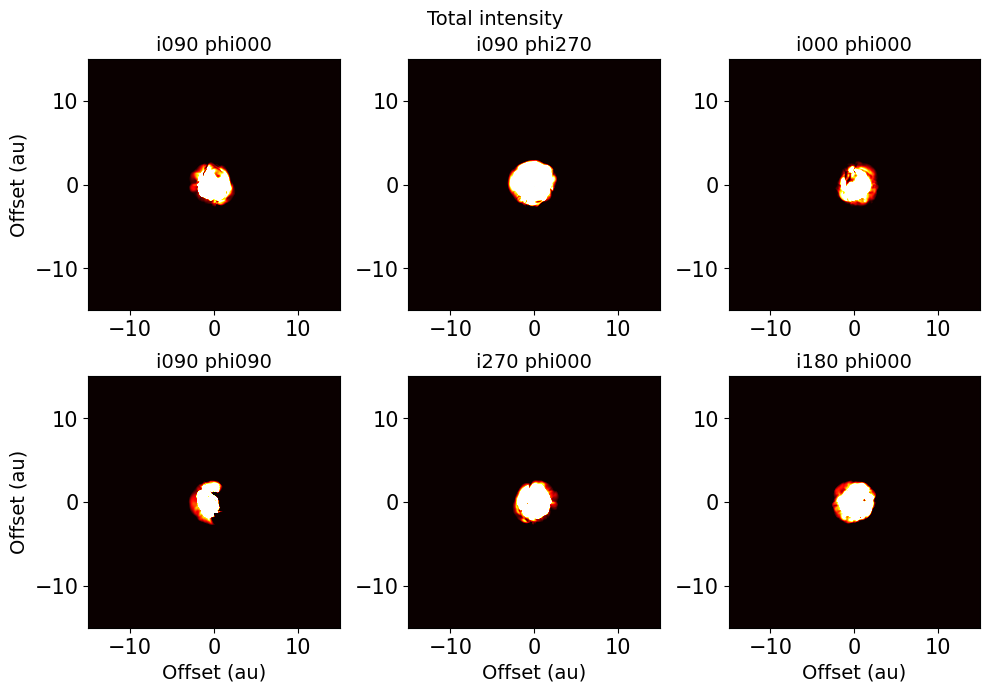

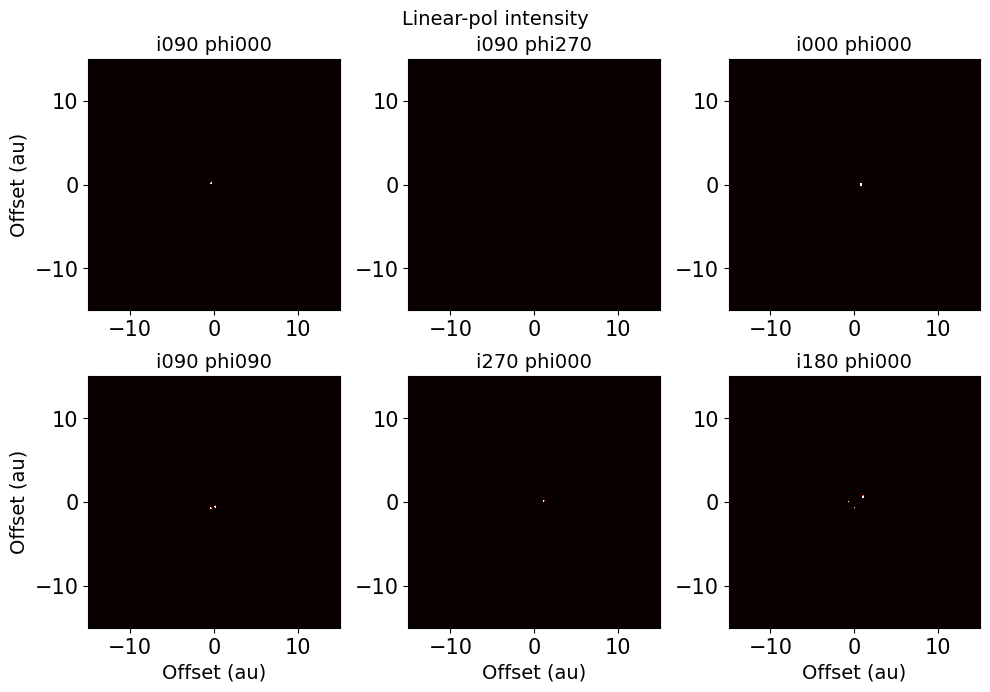

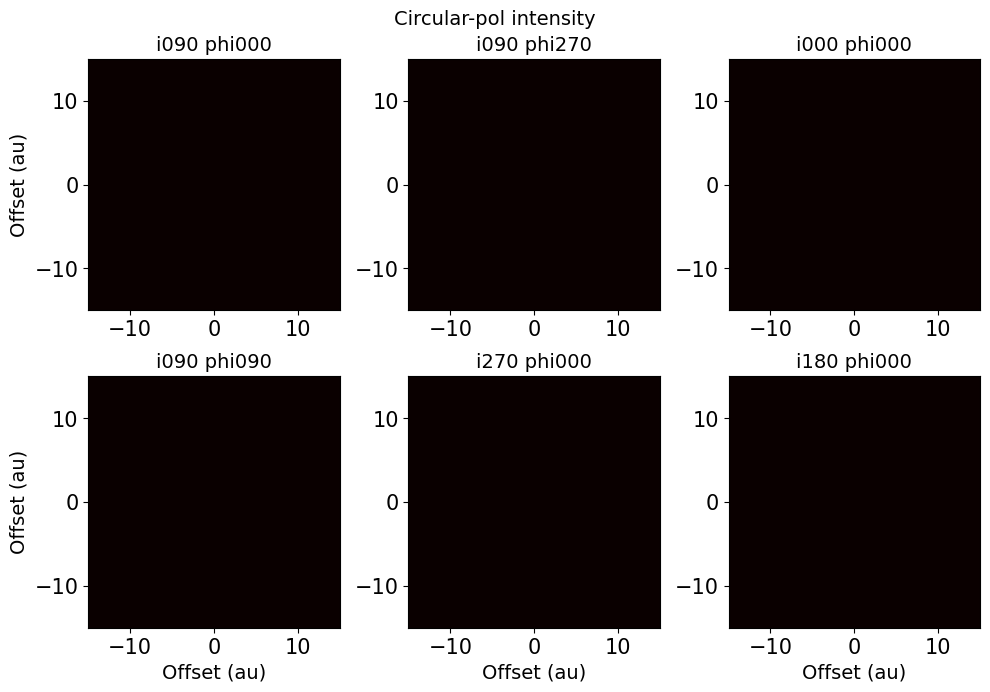

In [17]:
# Plot all images of one polarization and at one snapshot
# and one wavelenght only
#
import analyze_polarization_functions as apf
for polarization in ['i','l','v']:
    fig,ax,fluxtotal = apf.plot_intensity_onepolarization(
        imagepath='../r3dresults_polarized/st28gm06n075_images/209/',
        imagewave=0.65,
        polarization=polarization,
        vmaxcorr=1e-2
    )
    print(f'All total fluxes - {polarization}:')
    for flux in  fluxtotal:
        print(f'                     {flux:.3e} Jy')
    fig.set_figheight(7)
    fig.set_figwidth(10)
    fig.tight_layout()
    fig.subplots_adjust(top=0.92)
    #fig.show()


/tmp/ipykernel_43915/2843569559.py:12: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


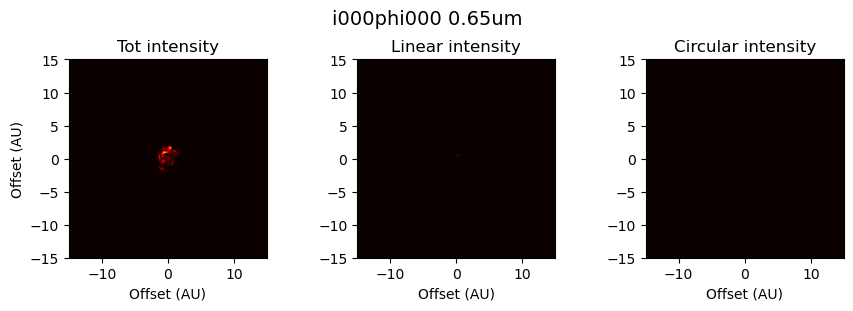

In [ ]:
# Plot all polarizations of one angle
# one snapshot, one wavelength
# 
import analyze_polarization_functions as apf
fig,ax = apf.plot_intensity_allpolarizations(
    imagepath='../r3dresults_polarized/st28gm06n052_images/166_optoolmgsio/',
    imagefile='image_i000_phi000_0.65um.out',
    distance=1,
    vmaxcorr=1
)
fig.tight_layout()
fig.show()

Qplusmax     Qnegmax      Uplusmax      Unegmax       Vrightmax        Vleftmax
 8.1771688930457e-13    -2.8792802522173e-97    5.8190993684909e-13    -3.1789109327758e-97    0.0    0.0


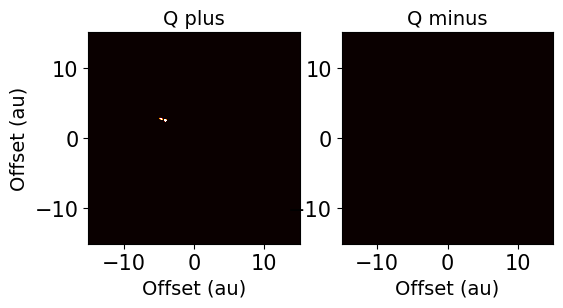

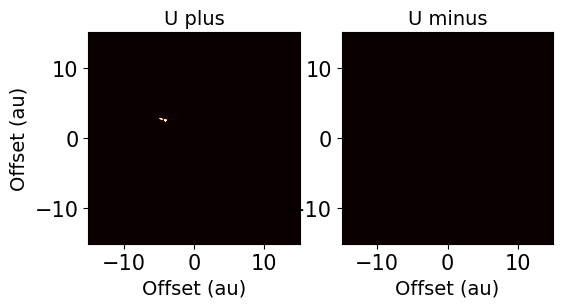

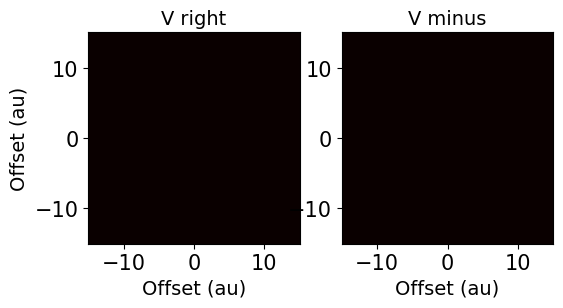

In [ ]:
# Plot all polarisation directions
# not intensities
import re
import os
import matplotlib.pyplot as plt
import numpy as np

# leftright(x), updown(y)
# 45deg, upright-downleft, upleft-downright
# righthand, lefthand

AUcm = 1.49598e13           # cm
imagewave = 0.65
imagepath = '../r3dresults_polarized/st28gm06n075_images/208/'
distance = 1
vmaxcorr = 1e-2

# Automatically add / to end of path if it's missing
if imagepath[-1] != '/':
    imagepath += '/'
# Set image file name
imagefile = f'image_i000_phi000_{imagewave}um.out'
#
# Start fig-objects for each polarization
fig_q,ax_q = plt.subplots(
    1,2,
    figsize=(6,6),
)
fig_u,ax_u = plt.subplots(
    1,2,
    figsize=(6,6),
)
fig_v,ax_v = plt.subplots(
    1,2,
    figsize=(6,6),
)
# Setup various lista and arrays
fluxtotal = []
q_pixeldata = []
u_pixeldata = []
v_pixeldata = []
#
# Open image file
with open(f'{imagepath}{imagefile}', 'r') as fimage:
    # Loop through image
    for nl,line in enumerate(fimage.readlines()):
        #
        # Check if polarised image or not
        if nl == 0:
            imagesetting = int(line.strip())
            #
        # Then check polarisation setting
        if imagesetting == 3:
            # 3 means full polarisation, continue with extracting data
            #
            # Row 1: image size, pixels by pixels
            if nl == 1:
                npixels_x = int(line.split()[0])
                npixels_y = int(line.split()[1])
                npixels = max([npixels_x,npixels_y])
            # row 3: pixel size is in cm, divide by AUcm for AU
            if nl == 3:
                pixelsize_au = float(line.split()[0])/AUcm
                #
            # row 6 onward: pixel-values, four columns
            # image.out's pixels has unit
            # erg s-1 cm-2 Hz-1 ster-1
            if nl > 5:
                if len(line.split()) > 1:
                    # Loop over polarisation numbers
                    # Split line and extract each column, strip from \n and make floats
                    q_pixeldata.append(
                        float(line.split()[1].strip())
                    )
                    u_pixeldata.append(
                        float(line.split()[2].strip())
                    )
                    v_pixeldata.append(
                        float(line.split()[3].strip())
                    )
# Continue with image plotting
#
# Abort if imagesetting is incorrect
if imagesetting == 1:
    raise ValueError('Not polarized, load normal image with a3d.load_images()!')
else:
    # Extract some useful quantities
    # pixel size in asec (pixelsize in au and distance in pc gives distance in asec)
    pixelsize_as = pixelsize_au / distance
    # Size of whole image in AU and image-axis-scales
    size_au = pixelsize_au * npixels
    axisplot  = [
        -0.5*size_au,0.5*size_au,-0.5*size_au,0.5*size_au
    ]
    # Extract max polarizations in each direction
    #
    # Total flux density of the image in Jy
    # Transform to Jy/pix and sum all
    # 1 Jy = 1e23 erg/(s cm2 Hz)
    # 1 asec = 1/(180/pi * 3600)^2 ster = 2.35044305391e-11 ster
    # 1 pixel = pixelsize_as^2  asec^2
    # So in effect unit is Jy/30x30AU2
    #
    qplus_max = np.max(q_pixeldata)
    qneg_max = np.min(q_pixeldata)
    #
    uplus_max = np.max(u_pixeldata)
    uneg_max = np.min(u_pixeldata)
    #
    vplus_max = np.max(v_pixeldata)
    vneg_max = np.min(v_pixeldata)
    #
    # Print min-max values of each
    print('Qplusmax     Qnegmax      Uplusmax      Unegmax       Vrightmax        Vleftmax')
    print(f' {qplus_max}    {qneg_max}    {uplus_max}    {uneg_max}    {vplus_max}    {vneg_max}')
    #
    # Loop through pixeldata and save in 2d-arrays
    qplus_strength_2d = np.zeros((npixels_x,npixels_y))
    qneg_strength_2d = np.zeros((npixels_x,npixels_y))
    #
    uplus_strength_2d = np.zeros((npixels_x,npixels_y))
    uneg_strength_2d = np.zeros((npixels_x,npixels_y))
    #
    vplus_strength_2d = np.zeros((npixels_x,npixels_y))
    vneg_strength_2d = np.zeros((npixels_x,npixels_y))
    #
    nx,ny = 0,0
    #
    for q_strength,u_strength,v_strength in zip(q_pixeldata,u_pixeldata,v_pixeldata):
        # Save in image arrays and
        # Recompute unit to Jy/asec2
        if q_strength > 0:
            qplus_strength_2d[nx,ny] =   q_strength * 1.e23 * 2.35044305391e-11 / distance**2
        else: 
            qneg_strength_2d[nx,ny] = -1*q_strength * 1.e23 * 2.35044305391e-11 / distance**2
        if u_strength > 0:
            uplus_strength_2d[nx,ny] =   u_strength * 1.e23 * 2.35044305391e-11 / distance**2
        else: 
            uneg_strength_2d[nx,ny] = -1*u_strength * 1.e23 * 2.35044305391e-11 / distance**2
        if v_strength > 0:
            vplus_strength_2d[nx,ny] =   v_strength * 1.e23 * 2.35044305391e-11 / distance**2
        else: 
            vneg_strength_2d[nx,ny] = -1*v_strength * 1.e23 * 2.35044305391e-11 / distance**2
        # Move nx and ny
        nx = nx + 1
        if nx == npixels_x:
            nx = 0
            ny = ny + 1
    # Plot Q-parameters
    ax_q[0].imshow(
        qplus_strength_2d,
        origin='lower',
        extent=axisplot,
        cmap=plt.get_cmap('hot'),
        vmin=0,
        vmax=np.max(qplus_strength_2d)*vmaxcorr
    )
    # Write out polarization
    ax_q[0].set_title(
        'Q plus', fontsize=14
    )
    ax_q[1].imshow(
        qneg_strength_2d,
        origin='lower',
        extent=axisplot,
        cmap=plt.get_cmap('hot'),
        vmin=0,
        vmax=np.max(qplus_strength_2d)*vmaxcorr
    )
    # Write out polarization
    ax_q[1].set_title(
        'Q minus', fontsize=14
    )
    #
    # Plot U-parameters
    #
    ax_u[0].imshow(
        uplus_strength_2d,
        origin='lower',
        extent=axisplot,
        cmap=plt.get_cmap('hot'),
        vmin=0,
        vmax=np.max(uplus_strength_2d)*vmaxcorr
    )
    # Write out polarization
    ax_u[0].set_title(
        'U plus', fontsize=14
    )
    ax_u[1].imshow(
        uneg_strength_2d,
        origin='lower',
        extent=axisplot,
        cmap=plt.get_cmap('hot'),
        vmin=0,
        vmax=np.max(uplus_strength_2d)*vmaxcorr
    )
    # Write out polarization
    ax_u[1].set_title(
        'U minus', fontsize=14
    )
    #
    # Plot V-parameters
    #
    ax_v[0].imshow(
        vplus_strength_2d,
        origin='lower',
        extent=axisplot,
        cmap=plt.get_cmap('hot'),
        vmin=0,
        vmax=np.max(vplus_strength_2d)*vmaxcorr
    )
    # Write out polarization
    ax_v[0].set_title(
        'V right', fontsize=14
    )
    ax_v[1].imshow(
        vneg_strength_2d,
        origin='lower',
        extent=axisplot,
        cmap=plt.get_cmap('hot'),
        vmin=0,
        vmax=np.max(vplus_strength_2d)*vmaxcorr
    )
    # Write out polarization
    ax_v[1].set_title(
        'V left', fontsize=14
    )
    # Set axis labels and tick sizes
    ax_q[0].set_ylabel(
        'Offset (au)',fontsize=14
    )
    ax_u[0].set_ylabel(
        'Offset (au)',fontsize=14
    )
    ax_v[0].set_ylabel(
        'Offset (au)',fontsize=14
    )
    for nplot in range(2):
        ax_q[nplot].set_xlabel(
            'Offset (au)',fontsize=14
        )
        ax_q[nplot].tick_params(
            axis='both', which='major', labelsize=15
        )
        ax_q[nplot].tick_params(
            axis='both', which='major', labelsize=15
        )
        #
        ax_u[nplot].set_xlabel(
            'Offset (au)',fontsize=14
        )
        ax_u[nplot].tick_params(
            axis='both', which='major', labelsize=15
        )
        ax_u[nplot].tick_params(
            axis='both', which='major', labelsize=15
        )
        #
        ax_v[nplot].set_xlabel(
            'Offset (au)',fontsize=14
        )
        ax_v[nplot].tick_params(
            axis='both', which='major', labelsize=15
        )
        ax_v[nplot].tick_params(
            axis='both', which='major', labelsize=15
        )